# Example: Registered Interest and Principal of Securities (STRIPS) Bonds
In this example, we separate a coupon Treasury security into zero-coupon [STRIPS](https://www.treasurydirect.gov/marketable-securities/strips/) and price the resulting cash flows from an issuer's perspective.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
>
> * __Generate STRIPS cash flows:__ Separate the coupon and principal payments of a selected Treasury security into individual zero-coupon claims.
> * __Apply alternative pricing assumptions:__ Price the claims under constant-yield, constant-discount, and upward-sloping yield-curve scenarios.
> * __Compare issuer pricing strategies:__ Explain how maturity-specific discount assumptions change the prices of the resulting securities.

Let's construct the STRIPS and compare the three pricing strategies.
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We'll explore `T-note` and `T-bond` prices from United States Treasury auctions between October 2022 and August 2023 downloaded as a `CSV` file using the [Auction query functionality of TreasuryDirect.gov](https://www.treasurydirect.gov/auctions/auction-query/). 

> __Dataset:__ We load the `CSV` dataset using [the local `MyTreasuryNotesAndBondsDataSet()` function](src/Files.jl), which returns the auction data as a `DataFrame`. We store the auction data in the `dataset::DataFrame` variable.

So what do we have?

In [2]:
dataset = MyTreasuryNotesAndBondsDataSet()

Row,CUSIP,Security Type,Security Term,Auction Date,Issue Date,Maturity Date,Price,High Yield,Interest Rate
,String15,String7,String7,String15,String15,String15,Float64,Float64,Float64
1,91282CHW4,Note,7-Year,08/29/2023,08/31/2023,08/31/2030,99.4773,0.04212,0.04125
2,91282CHV6,Note,2-Year,08/28/2023,08/31/2023,08/31/2025,99.9549,0.05024,0.05
3,91282CHX2,Note,5-Year,08/28/2023,08/31/2023,08/31/2028,99.8889,0.044,0.04375
4,912810TU2,Bond,20-Year,08/23/2023,08/31/2023,08/15/2043,98.3742,0.04499,0.04375
5,912810TT5,Bond,30-Year,08/10/2023,08/15/2023,08/15/2053,98.9127,0.04189,0.04125
6,91282CHT1,Note,10-Year,08/09/2023,08/15/2023,08/15/2033,98.9862,0.03999,0.03875
7,91282CHU8,Note,3-Year,08/08/2023,08/15/2023,08/15/2026,99.936,0.04398,0.04375
8,91282CHR5,Note,7-Year,07/27/2023,07/31/2023,07/31/2030,99.475,0.04087,0.04
9,91282CHQ7,Note,5-Year,07/25/2023,07/31/2023,07/31/2028,99.7988,0.0417,0.04125


___

## Task 1: Select a random note or bond from which we create separate marketable products
In this task, we'll select a random note or bond, compute its price, compare it to the auction price (to check our price codes), and then strip the selected note or bond.

First, let's determine how many notes and bonds we have in the `dataset::DataFrame` using the [nrow function](https://dataframes.juliadata.org/stable/lib/functions/#DataAPI.nrow) that is exported by the [DataFrames.jl package](https://github.com/JuliaData/DataFrames.jl). Then, we'll compute a random index using the [built-in Julia rand function](https://docs.julialang.org/en/v1/stdlib/Random/). We store the data for the random note or bond in the `random_note_or_bond::DataFrameRow` variable:

In [3]:
random_note_or_bond_data = let
    
    # initialize -
    number_of_notes_and_bonds = nrow(dataset); # how many notes and bonds do we have?
    i = rand(1:number_of_notes_and_bonds); # pick a random index
    random_note_or_bond = dataset[i,:];
    random_note_or_bond # return
end


Row,CUSIP,Security Type,Security Term,Auction Date,Issue Date,Maturity Date,Price,High Yield,Interest Rate
,String15,String7,String7,String15,String15,String15,Float64,Float64,Float64
5,912810TT5,Bond,30-Year,08/10/2023,08/15/2023,08/15/2053,98.9127,0.04189,0.04125


Get the parameters from the `random_note_or_bond::DataFrameRow` variable to test our price calculation.

> __Data we need:__ We set the face (par) value `Vₚ,` the duration `T` (which we convert to the number of years using [the `securityterm(...)` function](src/Utility.jl)), the yield field, i.e., the $y$ value in the discount rate, the coupon rate $\bar{c}$ and the number of coupon payments per year `λ`.

Let's gather that data and store it in the `random_note_or_bond_parameters::NamedTuple` variable.

In [4]:
random_note_or_bond_parameters = let
    
    Vₚ = 100.0; # face value of the note or bond
    T = random_note_or_bond_data[Symbol("Security Term")] |> String |> securityterm; # term as a Float64
    y = random_note_or_bond_data[Symbol("High Yield")]; # Effective discount rate
    c̄ = random_note_or_bond_data[Symbol("Interest Rate")]; # Interest rate (coupon rate)
    λ = 2; # number of coupon payments per year

    # package -
    data = (Vₚ=Vₚ, T=T, y=y, c̄=c̄, λ=λ) # this is a NamedTuple - a cool data structure!

    data; # return
end

(Vₚ = 100.0, T = 30.0, y = 0.04189, c̄ = 0.04125, λ = 2)

Next, we instantiate a discrete compounding model and store this model in the `discrete_compounding` variable, then compute the price of the random note or bond using [the `VLQuantitativeFinancePackage.jl` bond pricing functionality](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/). We store the populated bond in the `nominal_bond_model::MyUSTreasuryCouponSecurityModel` variable:

In [5]:
nominal_bond_model = let

    # Build a discrete compounding model -
    discrete_compounding = DiscreteCompoundingModel();

    # unpack parameters -
    Vₚ = random_note_or_bond_parameters.Vₚ; # face value of the note or bond
    T = random_note_or_bond_parameters.T; # term as a Float64
    y = random_note_or_bond_parameters.y; # Effective discount rate
    c̄ = random_note_or_bond_parameters.c̄; # Interest rate (coupon rate)
    λ = random_note_or_bond_parameters.λ; # number of coupon payments per year

    # Build a T-year model and compute the price using the short-hand syntax
    model = build(MyUSTreasuryCouponSecurityModel, (
            par = Vₚ, T = T, rate = y, coupon = c̄, λ = λ
    )) |> discrete_compounding;

    model; # return
end

MyUSTreasuryCouponSecurityModel(100.0, 0.04189, 0.04125, 30.0, 2, 98.91267173039739, Dict(5 => 1.8594402365681926, 56 => 0.6460446736086777, 35 => 0.9984166798625052, 55 => 0.6595760792974114, 60 => 29.42560554502223, 30 => 1.1074485545268005, 32 => 1.0624753611193534, 6 => 1.821293249458289, 45 => 0.811499697602439, 4 => 1.8983862123231134…), Dict(5 => 1.1092047807928354, 56 => 3.1925036831884754, 35 => 2.065770776469833, 55 => 3.127008490357929, 60 => 3.468492767084801, 30 => 1.8623889945671397, 32 => 1.9412214866113104, 6 => 1.132437074926541, 45 => 2.5415905958974703, 4 => 1.0864491043032047…))

#### Check 
Are the calculated and observed auction prices similar?

> __Test:__ Let's use the [isapprox function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox) combined with the [@assert macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert) to check the similarity of the computed and observed note (or bond) price. If the price values are different beyond an absolute tolerance of `atol = 1e-3`, a `false` result is generated, and an [AssertionError](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError) is thrown. Otherwise, a `true` result is generated, and the code continues to execute.

So what happens?

In [6]:
let
    observed_bond_price = random_note_or_bond_data[:Price];
    @assert isapprox(observed_bond_price, nominal_bond_model.price; atol = 1e-2) # we used absolute tolerance here
end

### Strip the note or bond to create a collection of zero-coupon payments
We generate a dictionary of zero-coupon bond models for a `MyUSTreasuryCouponSecurityModel` using [the `strip(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.strip) exported by the [`VLQuantitativeFinancePackage.jl package`](https://github.com/varnerlab/VLQuantitativeFinancePackage.jl). 

The resulting `strips::MyUSTreasuryZeroCouponBondModel` dictionary stores the generated bonds in order of duration, with their indexes serving as keys and the corresponding `MyUSTreasuryZeroCouponBondModel` instances as values in the dictionary.

In [7]:
strips = VLQuantitativeFinancePackage.strip(nominal_bond_model) # notice these are NOT priced yet!

Dict{Int64, MyUSTreasuryZeroCouponBondModel} with 61 entries:
  5  => MyUSTreasuryZeroCouponBondModel(2.0625, nothing, 2.5, nothing, 2, nothi…
  56 => MyUSTreasuryZeroCouponBondModel(2.0625, nothing, 28.0, nothing, 2, noth…
  35 => MyUSTreasuryZeroCouponBondModel(2.0625, nothing, 17.5, nothing, 2, noth…
  55 => MyUSTreasuryZeroCouponBondModel(2.0625, nothing, 27.5, nothing, 2, noth…
  60 => MyUSTreasuryZeroCouponBondModel(2.0625, nothing, 30.0, nothing, 2, noth…
  30 => MyUSTreasuryZeroCouponBondModel(2.0625, nothing, 15.0, nothing, 2, noth…
  32 => MyUSTreasuryZeroCouponBondModel(2.0625, nothing, 16.0, nothing, 2, noth…
  6  => MyUSTreasuryZeroCouponBondModel(2.0625, nothing, 3.0, nothing, 2, nothi…
  45 => MyUSTreasuryZeroCouponBondModel(2.0625, nothing, 22.5, nothing, 2, noth…
  4  => MyUSTreasuryZeroCouponBondModel(2.0625, nothing, 2.0, nothing, 2, nothi…
  13 => MyUSTreasuryZeroCouponBondModel(2.0625, nothing, 6.5, nothing, 2, nothi…
  54 => MyUSTreasuryZeroCouponBondModel(2.0625,

#### Check
Do we have the correct number of stripped products? For a parent note or bond of duration `T` years, there should be $\lambda\;{T}+1$ STRIPS, where $\lambda$ is the number of coupon payments per year. Let's verify that [the `strip(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.strip) produced the correct number of products. 

> __Test:__ Use the [@assert macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert) to check the number of STRIPS. If the incorrect number of products is in the strips dictionary, a `false` result is generated, and an [AssertionError](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError) is thrown. Otherwise, `true` is generated and the code runs without error.

So, what do we get?

In [8]:
let

    # unpack parameters -
    T = random_note_or_bond_parameters.T; # term as a Float64
    λ = random_note_or_bond_parameters.λ; # number of coupon payments per year

    number_of_strips = λ*T+1 |> Int # correct number of STRIPs
    @assert length(strips) == number_of_strips # soooo, I'm waiting!!!
end

## Task 2: Pricing the STRIPS products for secondary auction
STRIPS generally trade below maturity value when nominal yields are positive. A dealer may post an offer, but competitive prices are constrained by Treasury cash-flow equivalence, prevailing discount factors, liquidity, financing, taxes, and transaction costs. The three schemes below are deliberately hypothetical quoting experiments, not a description of how a dealer can set market prices independently.

> __Scheme 1 constant yield__: In this approach, the brokerage prices the zero-coupon instruments to have a constant yield $y$. This can be achieved by setting the price as an escalating fraction of the par value $V_{B} = \left(\alpha\right)^{T}\cdot{V}_{P}$, where $\alpha\leq{1}$ and $T$ represents the time to maturity of the generated zero coupon bond.

> __Scheme 2 constant discount__: The brokerage prices the zero-coupon instruments to have a constant discount, i.e., the ratio of price to face value is constant across all instruments. In this case, $V_{B} = \left(\alpha\right)\cdot{V}_{P}$ is not a function of the time to maturity of the instrument, and $\alpha\leq{1}$.

> __Scheme 3:__ In this scheme, we allow the yield to vary with the maturity of the bond. Suppose the yield at which we are willing to sell the bond is given by:
> $$
\bar{Y}_{i} = \theta_{1}+\theta_{2}\cdot\left(i-1\right)^{\beta}
> $$
> where $i$ denotes the STRIPS index, $\theta_{1}$ denotes the interest rate for the shortest term bond, $\theta_{2}$ governs how fast the rate escalates for each pass of the loop, i.e., for each bond of longer maturity that we sell, and $\beta$ is a sensitivity parameter. Because $\theta_{1}>{0}$, $\theta_{2}\geq{0}$, and $\beta>0$, this scheme will give a _normal_ yield curve $\bar{Y}_{i}\leq\bar{Y}_{i+1}$, i.e., longer-term maturities will have higher yields compared to shorter-term bonds.

Let's start with Scheme 1.

### Scheme 1: Constant yield STRIPS  
To start, let's specify a value for the escalation parameter $\alpha\leq{1}$:

In [9]:
α = 0.97; # must be less than 1

Next, for each zero in the `strips` dictionary, let's specify (or compute) the missing price and rate values. To compute the price value, we compute the discount `d` (which depends upon our choice of scheme and $\alpha$) which gives us the price. From the price we can compute the yield to maturity, i.e., the `rate` using [the yieldtomaturity(...) function](src/Compute.jl) that we developed in class.


In [10]:
strips = let

    strips = VLQuantitativeFinancePackage.strip(nominal_bond_model)
    number_of_strips = length(strips);
    for (k,v) ∈ strips

        # get data from this strip
        model = v;
        T = model.T # time to maturity
        Vₚ = model.par; # face value
        d = (α)^T; # we selected scheme 1
        model.price = (d)*Vₚ # set the price

        (ytm, ytm_estimates) = yieldtomaturity(model;
            TR = T,
            price = model.price,
            ϵ = 1e-10,
            maxiter = 1000,
        );
    
        # do a YTM calculation to compute the market rate of interest
        model.rate = ytm;
    end
    strips; # return
end

Dict{Int64, MyUSTreasuryZeroCouponBondModel} with 61 entries:
  5  => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0304592, 2.5, 1.91128, 2, not…
  56 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0304592, 28.0, 0.879028, 2, n…
  35 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0304592, 17.5, 1.21032, 2, no…
  55 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0304592, 27.5, 0.892517, 2, n…
  60 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0304592, 30.0, 0.827077, 2, n…
  30 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0304592, 15.0, 1.30608, 2, no…
  32 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0304592, 16.0, 1.2669, 2, not…
  6  => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0304592, 3.0, 1.88239, 2, not…
  45 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0304592, 22.5, 1.03934, 2, no…
  4  => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0304592, 2.0, 1.94061, 2, not…
  13 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0304592, 6.5, 1.69204, 2, not…
  54 => MyUSTreasuryZeroCouponBondModel(2.0625,

#### Visualize the first $m$ STRIPS products
`Unhide` the next code cell to see how we build a table displaying the bond price information. 

> __What's happening in the code below?__ First, specify the `number_of_strips_to_view.` Then, we'll loop through each STRIP and access the respective models from the `strips` dictionary using the bracket notation `strips[i],` where the index $i$ represents the STRIP index. Next, we'll add pricing, maturity, etc. data to the `strips_table_data_array` and display the resulting table by calling the `pretty_table(…)` function, which is exported by the [PrettyTables.jl package](https://github.com/ronisbr/PrettyTables.jl)

What do you see?

In [11]:
strips_table_data_array_S1 = let

    number_of_strips = length(strips);
    number_of_strips_to_view = number_of_strips ≥ 20 ? 20 : number_of_strips
    strips_table_data_array_S1 = Array{Any,2}(undef, number_of_strips, 6);
    strips_table_header_array = [["", "Maturity","Face","Price","y", "Discount"],
        ["","YR","USD","USD","", "price/face"]];
    for i ∈ 1:number_of_strips

        zc_model = strips[i];
        strips_table_data_array_S1[i,1] = i
        strips_table_data_array_S1[i,2] = zc_model.T
        strips_table_data_array_S1[i,3] = zc_model.par
        strips_table_data_array_S1[i,4] = zc_model.price
        strips_table_data_array_S1[i,5] = zc_model.rate  
        strips_table_data_array_S1[i,6] = (zc_model.price/zc_model.par)
    end
    pretty_table(strips_table_data_array_S1[1:number_of_strips_to_view,1:end], 
        column_labels=strips_table_header_array, table_format = TextTableFormat(borders = text_table_borders__simple))

    strips_table_data_array_S1; # return
end;

===== ========== ======== ========= =========== =============
       Maturity     Face     Price           y     Discount 
             YR      USD       USD               price/face 
===== ========== ======== ========= =========== =============
   1        0.5   2.0625   2.03133   0.0304592     0.984886
   2        1.0   2.0625   2.00062   0.0304592         0.97
   3        1.5   2.0625   1.97039   0.0304592     0.955339
   4        2.0   2.0625   1.94061   0.0304592       0.9409
   5        2.5   2.0625   1.91128   0.0304592     0.926679
   6        3.0   2.0625   1.88239   0.0304592     0.912673
   7        3.5   2.0625   1.85394   0.0304592     0.898879
   8        4.0   2.0625   1.82592   0.0304592     0.885293
   9        4.5   2.0625   1.79832   0.0304592     0.871912
  10        5.0   2.0625   1.77114   0.0304592     0.858734
  11        5.5   2.0625   1.74437   0.0304592     0.845755
  12        6.0   2.0625     1.718   0.0304592     0.832972
  13        6.5   2.0625   1.69204

`Unhide` the next code cell to see how we plotted the yield curve suggested by your choice of the $\alpha$ parameter.

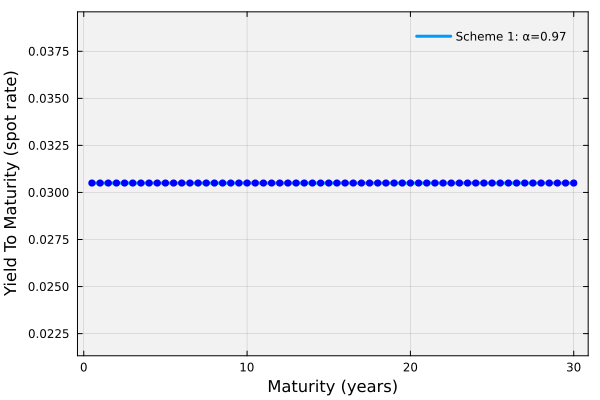

In [12]:
let
    plot(strips_table_data_array_S1[1:end-1,2], round.(strips_table_data_array_S1[1:end-1,5], digits=4),lw=3,
        label="Scheme 1: α=$(α)", ylims=(0.70*strips_table_data_array_S1[1,5], 1.3*strips_table_data_array_S1[1,5]))
    scatter!(strips_table_data_array_S1[1:end-1,2], round.(strips_table_data_array_S1[1:end-1,5], digits=4), 
    label="", msc="blue", mc="blue")
    xlabel!("Maturity (years)",fontsize=18)
    ylabel!("Yield To Maturity (spot rate)", fontsize=18)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

### Reassembly check for Scheme 1
How does the sum of the hypothetical STRIPS prices compare with the parent bond value? If the separated claims exactly reproduce the parent's Treasury cash flows, no-arbitrage requires their executable market values to add to the parent dirty value, apart from transaction, financing, and operational costs. A gap produced by our independently chosen pricing rule diagnoses internally inconsistent assumptions; it is not a guaranteed dealer profit.

In [13]:
let
    nominal_computed_price = nominal_bond_model.price;
    resale_total = sum(strips_table_data_array_S1[:,4]);
    println("Parent model value: $(nominal_computed_price) USD; hypothetical component sum: $(resale_total) USD")
end

Parent model value: 98.91267173039739 USD; hypothetical component sum: 120.60439688846506 USD


#### Summary Scheme 1 Pricing
* The constant yield (Scheme 1) pricing approach gives a constant yield curve and a decreasing discount. The short maturity zeros are more expensive relative to the face value of the original instrument.
* The observed yield $\bar{Y}$ is inversely proportional to the value of the escalation parameter $\alpha$; smaller values of $\alpha$ lead to higher yields $\bar{Y}$. On the other hand, $\alpha$ is directly proportional to the discount, i.e., the price of the zero relative to its face value.
* For the selected parameter values, the hypothetical component prices sum to more than the model parent price. In a frictionless market this would violate the reassembly condition and invite arbitrage until prices adjust. It should not be interpreted as a freely available stripping profit.

Next, let's explore Scheme 2.

### Scheme 2: Constant discount STRIPS
Now, let's consider scheme 2, which has a constant discount, i.e., the ratio of the auction price to the instrument's face value is constant. We'll use the same value of escalation parameter $\alpha$ and procedure as the previous Scheme 1 calculation, except we remove the time dependence on the `d` variable

In [14]:
strips = let

    strips = VLQuantitativeFinancePackage.strip(nominal_bond_model)
    number_of_strips = length(strips);
    for (k,v) ∈ strips

        # get data from this strip
        model = v;
        T = model.T # time to maturity
        Vₚ = model.par; # face value
        d = (α); # we selected scheme 2
        model.price = (d)*Vₚ # set the price

        (ytm, ytm_estimates) = yieldtomaturity(model;
            TR = T,
            price = model.price,
            ϵ = 1e-10,
            maxiter = 1000,
        );
    
        # do a YTM calculation to compute the market rate of interest
        model.rate = ytm;
    end
    strips # return
end

Dict{Int64, MyUSTreasuryZeroCouponBondModel} with 61 entries:
  5  => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0121837, 2.5, 2.00062, 2, not…
  56 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.00108783, 28.0, 2.00062, 2, n…
  35 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.00174053, 17.5, 2.00062, 2, n…
  55 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.00110761, 27.5, 2.00062, 2, n…
  60 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.00101531, 30.0, 2.00062, 2, n…
  30 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.00203061, 15.0, 2.00062, 2, n…
  32 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0019037, 16.0, 2.00062, 2, no…
  6  => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0101531, 3.0, 2.00062, 2, not…
  45 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.00135374, 22.5, 2.00062, 2, n…
  4  => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0152296, 2.0, 2.00062, 2, not…
  13 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.00468603, 6.5, 2.00062, 2, no…
  54 => MyUSTreasuryZeroCouponBondModel(2.0625,

#### Visualize the first $m$ STRIPS products
`Unhide` the next code cell to see how we build a table displaying the bond price information. 

> __What's happening in the code below?__ First, specify the `number_of_strips_to_view.` Then, we'll loop through each STRIP and access the respective models from the `strips` dictionary using the bracket notation `strips[i],` where the index $i$ represents the STRIP index. Next, we'll add pricing, maturity, etc. data to the `strips_table_data_array` and display the resulting table by calling the `pretty_table(…)` function, which is exported by the [PrettyTables.jl package](https://github.com/ronisbr/PrettyTables.jl)

What do you see?

In [15]:
strips_table_data_array_S2 = let


    number_of_strips = length(strips);
    number_of_strips_to_view = number_of_strips ≥ 20 ? 20 : number_of_strips
    strips_table_data_array = Array{Any,2}(undef, number_of_strips, 6);
    strips_table_header_array = [["", "Maturity","Face","Price","y", "Discount"],
        ["","YR","USD","USD","", "price/face"]];
    for i ∈ 1:number_of_strips

        zc_model = strips[i];
        strips_table_data_array[i,1] = i
        strips_table_data_array[i,2] = zc_model.T
        strips_table_data_array[i,3] = zc_model.par
        strips_table_data_array[i,4] = zc_model.price
        strips_table_data_array[i,5] = zc_model.rate  
        strips_table_data_array[i,6] = (zc_model.price/zc_model.par)
    end
    pretty_table(strips_table_data_array[1:number_of_strips_to_view,1:end], 
        column_labels=strips_table_header_array, table_format = TextTableFormat(borders = text_table_borders__simple))

    strips_table_data_array; # return
end;

===== ========== ======== ========= ============ =============
       Maturity     Face     Price            y     Discount 
             YR      USD       USD                price/face 
===== ========== ======== ========= ============ =============
   1        0.5   2.0625   2.00062    0.0609184         0.97
   2        1.0   2.0625   2.00062    0.0304592         0.97
   3        1.5   2.0625   2.00062    0.0203061         0.97
   4        2.0   2.0625   2.00062    0.0152296         0.97
   5        2.5   2.0625   2.00062    0.0121837         0.97
   6        3.0   2.0625   2.00062    0.0101531         0.97
   7        3.5   2.0625   2.00062   0.00870263         0.97
   8        4.0   2.0625   2.00062    0.0076148         0.97
   9        4.5   2.0625   2.00062   0.00676871         0.97
  10        5.0   2.0625   2.00062   0.00609184         0.97
  11        5.5   2.0625   2.00062   0.00553804         0.97
  12        6.0   2.0625   2.00062   0.00507653         0.97
  13        6.5   

`Unhide` the next code cell to see how we plotted the yield curve suggested by your choice of the $\alpha$ parameter.

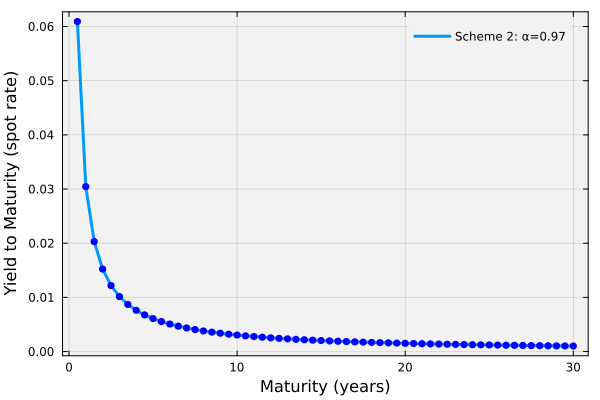

In [16]:
let
    plot(strips_table_data_array_S2[1:end-1,2], strips_table_data_array_S2[1:end-1,5],lw=3,
        label="Scheme 2: α=$(α)")
    scatter!(strips_table_data_array_S2[1:end-1,2], strips_table_data_array_S2[1:end-1,5], 
        label="", msc="blue", mc="blue")
    xlabel!("Maturity (years)",fontsize=18)
    ylabel!("Yield to Maturity (spot rate)", fontsize=18)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

#### Reassembly check for Scheme 2
Compare the sum of the hypothetical component prices with the parent dirty value. Any difference reflects the fact that Scheme 2 imposes component prices independently of the parent. Executable no-arbitrage prices, before market frictions, must satisfy the reassembly identity.

In [17]:
let
    nominal_computed_price = nominal_bond_model.price;
    resale_total = sum(strips_table_data_array_S2[:,4]);
    println("Parent model value: $(nominal_computed_price) USD; hypothetical component sum: $(resale_total) USD")
end

Parent model value: 98.91267173039739 USD; hypothetical component sum: 217.03749999999997 USD


#### Summary Scheme 2 Pricing
* The constant discount (Scheme 2) pricing approach gives an inverted yield curve. Under pricing scheme 2, short-maturity zeros yield more than longer-maturity bonds.
* The observed yield $\bar{Y}$ is inversely proportional to the value of the escalation parameter $\alpha$; smaller values of $\alpha$ lead to higher yields $\bar{Y}$. On the other hand, under this scheme, the discount is constant.
* The imposed constant-discount rule generates relative prices and yields that need not be consistent with the parent bond or with market STRIPS quotes. The short- versus long-maturity comparisons are properties of this hypothetical parameterization, not cash flows paid by or collected from Treasury.

Finally, let's explore Scheme 3.

### Scheme 3: Varying yield STRIPS
In this scheme, we allow the yield to vary with the maturity of the bond. Suppose the yield we are willing to sell the bond is given by:
$$
\bar{Y}_{i} = \theta_{1}+\theta_{2}\cdot\left(i-1\right)^{\beta}
$$
where $i$ is the index of the strip (a proxy for the maturity). Let's set values for the parameters $\theta_{1},$ $\theta_{2},$ and $\beta$:

In [18]:
θ₁, θ₂, β = 0.015, 0.001, 0.5; # parameters for scheme 3

We use the same procedure as before, except we compute the yield specified by the equation above, and then we compute the price from the yield.

In [19]:
strips_S3 = let

    strips = VLQuantitativeFinancePackage.strip(nominal_bond_model);
    discount_model = ContinuousCompoundingModel(); # Super interesting, this is what was needed to replicate the JPMorgan data!
    number_of_strips = length(strips);
    for (k,v) ∈ strips

        # get data from this strip
        model = v;
        T = model.T # time to maturity
        Vₚ = model.par; # face value
        Ȳ = θ₁ + θ₂*(k-1)^β; # set the rate

        model.rate = Ȳ
        model |> discount_model; # set the model
        strips[k] = model; # update
    end
    strips; # return
end;

In [20]:
strips_S3

Dict{Int64, MyUSTreasuryZeroCouponBondModel} with 61 entries:
  5  => MyUSTreasuryZeroCouponBondModel(2.0625, 0.017, 2.5, 1.97668, 2, Dict(0=…
  56 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0224162, 28.0, 1.10105, 2, Di…
  35 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.020831, 17.5, 1.43244, 2, Dic…
  55 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0223485, 27.5, 1.11554, 2, Di…
  60 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0226811, 30.0, 1.04444, 2, Di…
  30 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0203852, 15.0, 1.51914, 2, Di…
  32 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0205678, 16.0, 1.48414, 2, Di…
  6  => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0172361, 3.0, 1.95856, 2, Dic…
  45 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0216332, 22.5, 1.26766, 2, Di…
  4  => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0167321, 2.0, 1.99462, 2, Dic…
  13 => MyUSTreasuryZeroCouponBondModel(2.0625, 0.0184641, 6.5, 1.82924, 2, Dic…
  54 => MyUSTreasuryZeroCouponBondModel(2.0625,

#### Visualize the first $m$ STRIPS products
`Unhide` the next code cell to see how we build a table displaying the bond price information. 

> __What's happening in the code below?__ First, specify the `number_of_strips_to_view.` Then, we'll loop through each STRIP and access the respective models from the `strips` dictionary using the bracket notation `strips[i],` where the index $i$ represents the STRIP index. Next, we'll add pricing, maturity, etc. data to the `strips_table_data_array` and display the resulting table by calling the `pretty_table(…)` function, which is exported by the [PrettyTables.jl package](https://github.com/ronisbr/PrettyTables.jl)

What do you see?

In [21]:
strips_table_data_array_S3 = let

    number_of_strips = length(strips_S3);
    number_of_strips_to_view = number_of_strips ≥ 20 ? 20 : number_of_strips
    strips_table_data_array = Array{Any,2}(undef, number_of_strips, 6);
    strips_table_header_array = [["", "Maturity","Face","Price","y", "Discount"],
        ["","YR","USD","USD","", "price/face"]];
    for i ∈ 1:number_of_strips

        zc_model = strips_S3[i];
        strips_table_data_array[i,1] = i
        strips_table_data_array[i,2] = zc_model.T
        strips_table_data_array[i,3] = zc_model.par
        strips_table_data_array[i,4] = zc_model.price
        strips_table_data_array[i,5] = zc_model.rate  
        strips_table_data_array[i,6] = (zc_model.price/zc_model.par)
    end
    pretty_table(strips_table_data_array[1:number_of_strips_to_view,1:end], 
        column_labels=strips_table_header_array, table_format = TextTableFormat(borders = text_table_borders__simple))

    strips_table_data_array; # return
end;

===== ========== ======== ========= =========== =============
       Maturity     Face     Price           y     Discount 
             YR      USD       USD               price/face 
===== ========== ======== ========= =========== =============
   1        0.5   2.0625   2.04709       0.015     0.992528
   2        1.0   2.0625   2.02976       0.016     0.984127
   3        1.5   2.0625   2.01234   0.0164142     0.975679
   4        2.0   2.0625   1.99462   0.0167321      0.96709
   5        2.5   2.0625   1.97668       0.017      0.95839
   6        3.0   2.0625   1.95856   0.0172361     0.949606
   7        3.5   2.0625   1.94031   0.0174495     0.940754
   8        4.0   2.0625   1.92194   0.0176458      0.93185
   9        4.5   2.0625   1.90349   0.0178284     0.922906
  10        5.0   2.0625   1.88498       0.018     0.913931
  11        5.5   2.0625   1.86643   0.0181623     0.904935
  12        6.0   2.0625   1.84784   0.0183166     0.895924
  13        6.5   2.0625   1.82924

`Unhide` the next code cell to see how we plotted the yield curve suggested by your choice of the $\theta_{1},$ $\theta_{2},$ and $\beta$ parameters.

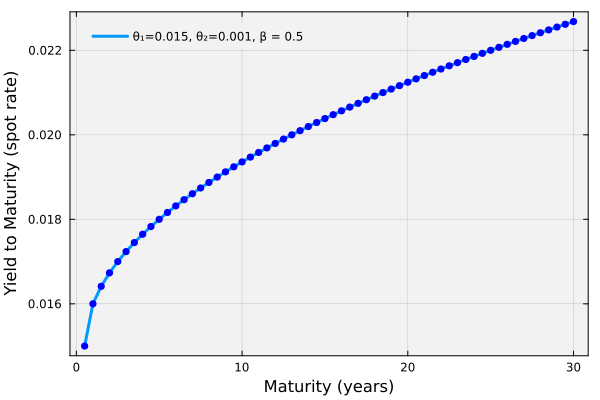

In [22]:
let

    plot(strips_table_data_array_S3[1:end-1,2], strips_table_data_array_S3[1:end-1,5],lw=3,
    label="θ₁=$(θ₁), θ₂=$(θ₂), β = $(β)")
    scatter!(strips_table_data_array_S3[1:end-1,2], strips_table_data_array_S3[1:end-1,5], 
    label="", msc="blue", mc="blue")
    xlabel!("Maturity (years)",fontsize=18)
    ylabel!("Yield to Maturity (spot rate)", fontsize=18)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

#### Curious: How much do we collect from the sale of the STRIPS?
In this scenario, we purchased an original instrument from the [United States Treasury](https://www.treasurydirect.gov/) for $V_{B}$, stripped the coupons and face, and resold them. How much did we make from the sale of the STRIPS?

In [23]:
let
    nominal_computed_price = nominal_bond_model.price;
    resale_total = sum(strips_table_data_array_S3[:,4]);
    println("Parent model value: $(nominal_computed_price) USD; hypothetical component sum: $(resale_total) USD")
end

Parent model value: 98.91267173039739 USD; hypothetical component sum: 141.97059398187753 USD


#### Summary Scheme 3 Pricing
* The varying yield (Scheme 3) pricing approach creates an upward-sloping yield curve where longer-maturity bonds have higher yields than shorter-maturity bonds. This reflects a more realistic market structure.
* The yield for each STRIP is determined by the formula $\bar{Y}_{i} = \theta_{1}+\theta_{2}\cdot\left(i-1\right)^{\beta}$, which allows for flexible control over the yield curve shape through the parameters $\theta_{1}$, $\theta_{2}$, and $\beta$.
* An upward-sloping curve may resemble some market snapshots, but shape alone does not make the prices market-consistent or reveal investor expectations without additional assumptions about term premia.
* The parameters generate hypothetical component prices. Before interpreting their sum as dealer revenue or profit, enforce the parent-bond reassembly identity and include transaction, financing, inventory, and operational costs.

## Summary

This example separated the coupon and principal payments of a Treasury security into individually marketable zero-coupon STRIPS and priced those claims under alternative discounting assumptions.

> __Key Takeaways__
>
> * __Stripping changes packaging, not promised cash flows:__ Each coupon and the principal payment becomes a separate zero-coupon claim with its own maturity date and face value.
> * __Each STRIP is valued from its own payment date:__ Its price is the present value of one future payment, so maturity and the applicable discount rate determine value.
> * __The assumed term structure changes relative prices:__ Constant-yield, constant-discount, and maturity-dependent yield schemes assign different values to otherwise identical promised payments at different dates.

STRIPS pricing therefore makes the role of the yield curve explicit: separating the cash flows exposes how discount rates at individual maturities determine value.

___


## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance.  Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.